# Evaluación de estrategias de balanceo en los modelos de ML seleccionados

Este notebook evalúa el efecto de distintas estrategias de balanceo sobre los modelos
de machine learning seleccionados para el proyecto: regresión logística, Random Forest
y XGBoost.

Se comparan cuatro escenarios: sin balanceo, pesos de clase, RandomOverSampler (ROS)
y SMOTE. El objetivo es identificar, para cada modelo, la estrategia que ofrece el
mejor desempeño considerando tanto las métricas de clasificación como la prioridad
de detectar clientes con riesgo de abandono.

Las técnicas de sobremuestreo, ROS y SMOTE, se aplican exclusivamente sobre el
conjunto de entrenamiento. Los conjuntos de validación y prueba conservan su
distribución original para evitar filtración de información y obtener una evaluación
representativa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga de artefactos preprocesados

In [2]:
ruta_artefactos = Path("../artifacts")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")

X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = artefactos["y_train"]
y_val = artefactos["y_val"]
y_test = artefactos["y_test"]
pesos_clase = artefactos["pesos_clase"]

relacion_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

print("X_train:", X_train.shape)
print("Pesos de clase:", pesos_clase)
print(f"Relación de desbalance: {relacion_desbalance:.2f} a 1")

X_train: (7000, 58)
Pesos de clase: {0: 0.5568814638027049, 1: 4.895104895104895}
Relación de desbalance: 8.79 a 1


## 2. Preparación de los conjuntos de entrenamiento por estrategia de balanceo

Se generan, a partir de `X_train`/`y_train`, los conjuntos de entrenamiento
correspondientes a ROS y SMOTE. El escenario "sin balanceo" y "pesos" reutilizan
`X_train`/`y_train` tal cual; la diferencia entre ambos está en el modelo (ver más
abajo), no en los datos.

In [3]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original:", X_train.shape, "- distribución:", np.bincount(y_train))
print("ROS:", X_train_ros.shape, "- distribución:", np.bincount(y_train_ros))
print("SMOTE:", X_train_smote.shape, "- distribución:", np.bincount(y_train_smote))

Original: (7000, 58) - distribución: [6285  715]
ROS: (12570, 58) - distribución: [6285 6285]
SMOTE: (12570, 58) - distribución: [6285 6285]


## 3. Función de evaluación y constructores de modelos por escenario

Para cada técnica de ML se definen los cuatro escenarios de balanceo. En "sin balanceo"
y "pesos" se usa `X_train`/`y_train` originales (la diferencia es si el modelo recibe
`class_weight`/`scale_pos_weight` o no); en "ROS" y "SMOTE" el modelo se entrena sin
peso adicional porque el desbalance ya se corrigió en los datos.

In [4]:
def evaluar_modelo(modelo, X, y_true):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


def construir_logreg(escenario):
    class_weight = pesos_clase if escenario == "pesos" else None
    return LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE)


def construir_rf(escenario):
    class_weight = "balanced_subsample" if escenario == "pesos" else None
    return RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=4,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def construir_xgb(escenario):
    scale_pos_weight = relacion_desbalance if escenario == "pesos" else 1.0
    return XGBClassifier(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    )


constructores = {
    "Regresión logística": construir_logreg,
    "Random Forest": construir_rf,
    "XGBoost": construir_xgb,
}

datos_por_escenario = {
    "sin balanceo": (X_train, y_train),
    "pesos": (X_train, y_train),
    "ROS": (X_train_ros, y_train_ros),
    "SMOTE": (X_train_smote, y_train_smote),
}

## 4. Entrenamiento de los 12 escenarios (3 modelos × 4 escenarios de balanceo)

Se entrena cada combinación de modelo y escenario de balanceo, y se evalúa en el
conjunto de validación.

In [5]:
resultados = []
modelos_entrenados = {}

for nombre_modelo, constructor in constructores.items():
    for nombre_escenario, (X_entrenamiento, y_entrenamiento) in datos_por_escenario.items():
        modelo = constructor(nombre_escenario)
        modelo.fit(X_entrenamiento, y_entrenamiento)

        metricas = evaluar_modelo(modelo, X_val, y_val)
        metricas["modelo"] = nombre_modelo
        metricas["balanceo"] = nombre_escenario
        resultados.append(metricas)

        modelos_entrenados[(nombre_modelo, nombre_escenario)] = modelo

tabla_balanceo = pd.DataFrame(resultados)[
    ["modelo", "balanceo", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].round(3)

tabla_balanceo

,modelo,balanceo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regresión logística,sin balanceo,0.896,0.286,0.013,0.025,0.751,0.223
1,Regresión logística,pesos,0.700,0.207,0.686,0.318,0.750,0.224
2,Regresión logística,ROS,0.705,0.215,0.712,0.330,0.751,0.221
3,Regresión logística,SMOTE,0.702,0.207,0.680,0.318,0.738,0.219
4,Random Forest,sin balanceo,0.898,0.000,0.000,0.000,0.818,0.327
5,Random Forest,pesos,0.817,0.304,0.614,0.407,0.820,0.312
6,Random Forest,ROS,0.776,0.278,0.752,0.406,0.818,0.302
7,Random Forest,SMOTE,0.869,0.186,0.085,0.117,0.773,0.231
8,XGBoost,sin balanceo,0.898,0.500,0.059,0.105,0.818,0.322
9,XGBoost,pesos,0.731,0.248,0.810,0.380,0.819,0.329


## 5. Comparación visual por modelo

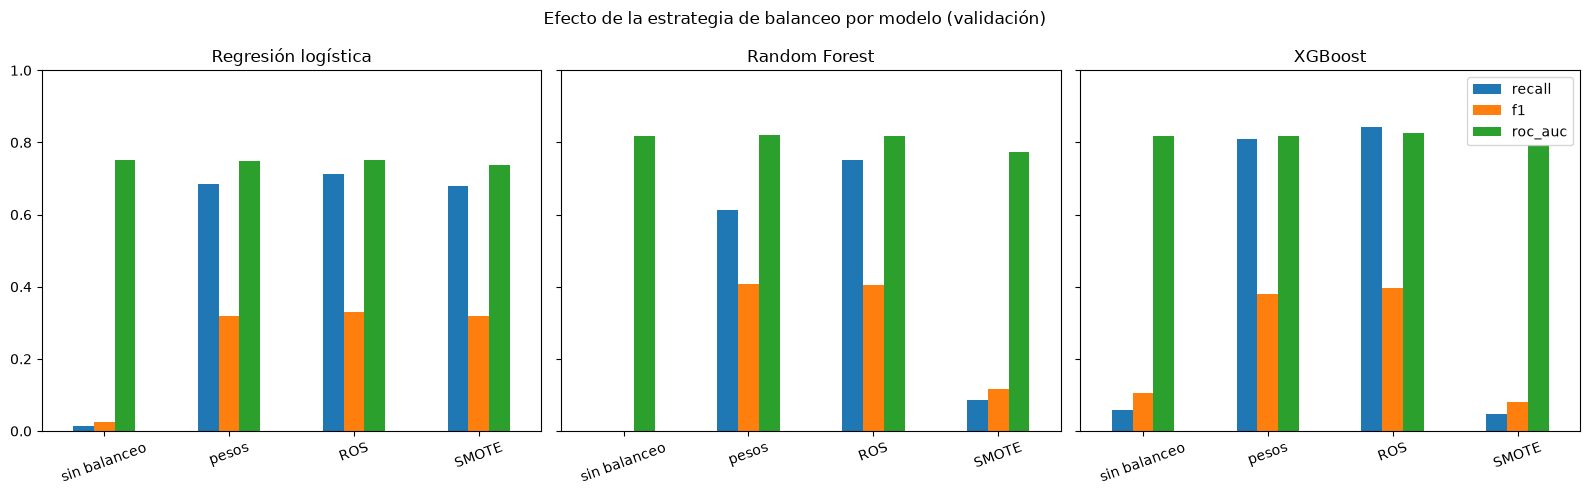

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

metricas_a_graficar = ["recall", "f1", "roc_auc"]

for ax, nombre_modelo in zip(axes, constructores.keys()):
    subtabla = (
        tabla_balanceo[tabla_balanceo["modelo"] == nombre_modelo]
        .set_index("balanceo")[metricas_a_graficar]
    )
    subtabla.plot(kind="bar", ax=ax, legend=(nombre_modelo == "XGBoost"))
    ax.set_title(nombre_modelo)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Efecto de la estrategia de balanceo por modelo (validación)")
plt.tight_layout()

ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)
plt.savefig(ruta_figuras / "09_01_balanceo_por_modelo.png", dpi=150)
plt.show()

## 6. Selección de la estrategia de balanceo por modelo

Como criterio inicial, se selecciona para cada modelo la estrategia que obtiene el
mayor F1. Cuando las diferencias de F1 son marginales, se prioriza la alternativa con
mayor recall, debido a que el objetivo del proyecto es detectar oportunamente a los
clientes con riesgo de abandono.

Para este análisis, se considera marginal una diferencia absoluta de F1 menor o igual a 0,01.

En Random Forest, los pesos de clase y RandomOverSampler obtienen valores de F1
prácticamente idénticos: 0,407 y 0,406, respectivamente. Sin embargo, ROS alcanza un
recall considerablemente mayor, de 0,752 frente a 0,614.

Por esta razón, se selecciona ROS para Random Forest, aceptando una disminución en la
precisión a cambio de detectar una mayor proporción de los clientes que abandonan.

In [7]:
eleccion_por_f1 = (
    tabla_balanceo
    .sort_values("f1", ascending=False)
    .groupby("modelo", sort=False)
    .first()
    .loc[list(constructores.keys())]
)

print("Elección automática por F1:")
display(eleccion_por_f1)

# En Random Forest, la diferencia de F1 entre pesos y ROS es marginal.
# Según el criterio definido, se selecciona ROS por su mayor recall:
# 0.752 frente a 0.614.
escenario_seleccionado_rf = "ROS"

eleccion_por_modelo = eleccion_por_f1.copy()
eleccion_por_modelo.loc["Random Forest"] = (
    tabla_balanceo[
        (tabla_balanceo["modelo"] == "Random Forest")
        & (tabla_balanceo["balanceo"] == escenario_seleccionado_rf)
    ]
    .set_index("modelo")
    .loc["Random Forest"]
)

print("\nSelección por modelo según el criterio definido:")
eleccion_por_modelo

Elección automática por F1:


,balanceo,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,
Regresión logística,ROS,0.705,0.215,0.712,0.330,0.751,0.221
Random Forest,pesos,0.817,0.304,0.614,0.407,0.820,0.312
XGBoost,ROS,0.737,0.259,0.843,0.396,0.826,0.333



Selección por modelo según el criterio definido:


,balanceo,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,,
Regresión logística,ROS,0.705,0.215,0.712,0.330,0.751,0.221
Random Forest,ROS,0.776,0.278,0.752,0.406,0.818,0.302
XGBoost,ROS,0.737,0.259,0.843,0.396,0.826,0.333


## 7. Guardado de la tabla de balanceo y de los modelos elegidos

Se guarda la tabla completa de resultados de los tres modelos de machine learning—
estos son los modelos que se usarán en `05_modelamiento_dl.ipynb` para la comparación
final contra las arquitecturas de deep learning.

In [8]:
ruta_modelos = Path("../models")
ruta_modelos.mkdir(exist_ok=True)

tabla_balanceo.to_csv(ruta_modelos / "resultados_balanceo_12_escenarios.csv", index=False)
eleccion_por_modelo.to_csv(ruta_modelos / "eleccion_balanceo_por_modelo.csv")

nombres_archivo = {
    "Regresión logística": "logistic_regression_final.joblib",
    "Random Forest": "random_forest_final.joblib",
    "XGBoost": "xgboost_final.joblib",
}

for nombre_modelo, nombre_archivo in nombres_archivo.items():
    escenario_elegido = eleccion_por_modelo.loc[nombre_modelo, "balanceo"]
    modelo_final = modelos_entrenados[(nombre_modelo, escenario_elegido)]
    joblib.dump(modelo_final, ruta_modelos / nombre_archivo)
    print(f"{nombre_modelo}: se guarda la versión '{escenario_elegido}' en {nombre_archivo}")

Regresión logística: se guarda la versión 'ROS' en logistic_regression_final.joblib
Random Forest: se guarda la versión 'ROS' en random_forest_final.joblib
XGBoost: se guarda la versión 'ROS' en xgboost_final.joblib


## 8. Conclusiones

La comparación de los 12 escenarios muestra que el efecto de las estrategias de
balanceo varía según el modelo. Aunque ROS fue finalmente seleccionada para los tres
modelos, las diferencias observadas permiten identificar distintos comportamientos:

- **Regresión logística:** ROS obtiene el mejor F1 (0,330) y un recall de 0,712,
  presentando una mejora frente a las demás configuraciones evaluadas.

- **Random Forest:** los pesos de clase alcanzan el mayor F1 (0,407) y la mayor
  precisión (0,304). Sin embargo, ROS obtiene un F1 prácticamente equivalente
  (0,406) y aumenta el recall de 0,614 a 0,752. Debido a la prioridad asignada a la
  detección del churn, se selecciona ROS.

- **XGBoost:** ROS obtiene el mejor desempeño del modelo y alcanza el mayor recall
  (0,843), ROC-AUC (0,826) y PR-AUC (0,333) de toda la comparación. Random Forest
  conserva un F1 ligeramente superior, pero XGBoost muestra una mayor capacidad para
  detectar clientes con riesgo de abandono.

Los modelos sin balanceo presentan una accuracy elevada, pero un recall muy bajo o
incluso nulo. Esto demuestra que la accuracy, por sí sola, no representa adecuadamente
el desempeño en un problema con una clase positiva minoritaria.

SMOTE presenta resultados inferiores a ROS y a los pesos de clase en Random Forest
y XGBoost. Una posible explicación es que la interpolación realizada por SMOTE sobre
variables transformadas mediante one-hot encoding genere observaciones sintéticas
poco representativas. Sin embargo, esta hipótesis requeriría un análisis adicional
para ser confirmada.

De acuerdo con el criterio establecido, ROS se selecciona como estrategia de balanceo
para los tres modelos de machine learning. Entre ellos, XGBoost ofrece el perfil más
orientado a maximizar la detección del churn, mientras que Random Forest mantiene un
mejor equilibrio entre precisión y recall. La selección definitiva se realizará
después de comparar estos resultados con los modelos de deep learning.